# Olist ML Pipeline — Late-Delivery Risk (and Repeat-Purchase)

**Development surface for the executable pipeline in `src/` + `run.sh`.**
This notebook is intentionally *thin*: every stage calls an importable function in
`src/`, so the exact same logic runs non-interactively via `./run.sh`. There is no
hidden state and no out-of-order dependency — it runs top-to-bottom.

| Doc | Purpose |
| --- | --- |
| `readme-mlp.md` | the assignment brief / requirements |
| `mlp-plan-result.md` | the plan (§A) and results (§B) — read this for rationale |
| `../eda/eda-plan-result.md` | the EDA this pipeline operationalises |

### The task (carried from the EDA)
The EDA's smoking gun: **late delivery → low review → no repeat purchase**
(on-time avg review 4.30 / late 2.57; repeat 3.13% vs 2.56%). The most *controllable,
leak-free* lever is the first link — so the **primary task is predicting `P(late delivery)`
at order time** so logistics can intervene on the toxic ~8% tail *before* it becomes a
1–2★ review and a lost customer. `repeat_purchase` is a config-switchable secondary task.

## 0. Setup
Import the pipeline modules and load configuration. Switching model/target/threshold is
a **config change**, never a code change — change `config.yaml` or pass `--set` to `run.sh`.

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from src.config import load_config, resolve_path
from src import ingest, labels, features, model as model_mod, evaluate as ev, pipeline

# Override here exactly as you would on the CLI: load_config(overrides=["model.name=random_forest"]).
cfg = load_config()
print('target :', cfg['target'])
print('model  :', cfg['model']['name'])
print('search :', cfg['search']['enabled'])

target : late_delivery
model  : hist_gbm
search : False


## 1. Data ingestion (BigQuery → order grain)
`ingest.load_data` pulls **one row per order** from the gold mart (`fact_orders` is
order-*item* grain, aggregated up here — the unit a logistics team acts on). Auth tries
the service-account keyfile first, then falls back to gcloud ADC. A parquet cache makes
reruns instant. The ingestion layer is a single swappable function.

In [2]:
raw = ingest.load_data(cfg)
raw.head(3)

📦 Loading cached order-grain table: /Users/cheonghoongjun/Documents/dev/github-dev/sctp-dsai-forked/dsai-m2-elt/m2-elt/my-work/HoongJun/dev/p5_analytics/notebooks/mlp/artifacts/orders.parquet
✅ Loaded 99,441 orders, 17 columns.


,order_id,customer_id,order_status,purchase_ts,approved_ts,delivered_ts,estimated_ts,order_gmv,order_freight,item_count,seller_count,total_weight_g,max_volume_cm3,product_category,seller_state,customer_unique_id,customer_state
0,76ee52772850236ff2a3b3a6b32f1cfe,3d4a22b0d2191f033ffe083fa365e051,delivered,2017-05-10 22:44:23,2017-05-12 02:50:17,2017-05-24 07:07:42,2017-05-30,37.9,15.10,1,1,300.0,3248.0,fashion_shoes,PR,84458bbb7df85664ecfd7092b5f0b75f,SP
1,333e7a046c4e6cc445f3178043b57039,4688c6355c8b84b24a780915fa1cf4eb,delivered,2017-05-08 23:25:31,2017-05-08 23:35:20,2017-05-23 14:43:09,2017-06-06,19.9,17.63,1,1,200.0,560.0,dvds_blu_ray,GO,d99f83104bb71e584298ceb4278597ef,RJ
2,6448b940e7bdf635ae69dca1b81077bc,f9b37f6a2591a3a3ee8ebbb20196d71d,delivered,2017-05-08 19:11:43,2017-05-08 19:25:18,2017-05-17 14:47:56,2017-05-31,49.9,15.10,1,1,450.0,8000.0,fashion_sport,SP,6a73ed08af9ee3b724f250866c331e48,PR


In [3]:
raw[['order_gmv','order_freight','item_count','total_weight_g']].describe()

,order_gmv,order_freight,item_count,total_weight_g
count,98666.000000,98666.000000,99441.0,98650.000000
mean,137.754076,22.823562,1.140626,2390.415307
std,210.645145,21.650909,0.536495,4773.529840
min,0.850000,0.000000,1.0,0.000000
25%,45.900000,13.850000,1.0,300.000000
50%,86.900000,17.170000,1.0,750.000000
75%,149.900000,24.040000,1.0,2068.750000
max,13440.000000,1794.960000,21.0,184400.000000


## 2. Labels (leakage-aware)
`late = delivered_ts > estimated_ts`, defined only on **delivered** orders with both
dates present. The class balance (~8% positive) is what drives our imbalanced-metric
and threshold choices below.

In [4]:
labelled = labels.make_labels(raw, cfg)
labelled['label'].value_counts(normalize=True).rename('share')

🎯 Target 'late_delivery': 96,470 rows, 7,826 positive (8.1%).


label
0    0.918876
1    0.081124
Name: share, dtype: float64

## 3. Feature engineering
`features.engineer` derives only **order-time** signals (no actual delivery/carrier
dates, no review score). EDA links: state/lane concentration, freight & weight as
distance/bulk proxies, and the *promised* lead time itself. The feature-processing
contract is summarised below and applied via a `ColumnTransformer`.

In [5]:
feats = features.engineer(labelled)
features.feature_table()

,feature,type,processing
0,order_gmv,numeric,median impute + StandardScaler
1,order_freight,numeric,median impute + StandardScaler
2,item_count,numeric,median impute + StandardScaler
3,seller_count,numeric,median impute + StandardScaler
4,total_weight_g,numeric,median impute + StandardScaler
5,max_volume_cm3,numeric,median impute + StandardScaler
6,estimated_lead_days,numeric,median impute + StandardScaler
7,purchase_dow,numeric,median impute + StandardScaler
8,purchase_month,numeric,median impute + StandardScaler
9,purchase_hour,numeric,median impute + StandardScaler


In [6]:
X, y = features.split_X_y(feats)
print('feature matrix:', X.shape)
X.head(3)

feature matrix: (96470, 15)


,order_gmv,order_freight,item_count,seller_count,total_weight_g,max_volume_cm3,estimated_lead_days,purchase_dow,purchase_month,purchase_hour,freight_ratio,customer_state,seller_state,product_category,same_state
0,37.9,15.10,1,1,300.0,3248.0,19.052512,2,5,22,0.398417,SP,PR,fashion_shoes,cross
1,19.9,17.63,1,1,200.0,560.0,28.023947,0,5,23,0.885930,RJ,GO,dvds_blu_ray,cross
2,49.9,15.10,1,1,450.0,8000.0,22.200197,0,5,19,0.302605,PR,SP,fashion_sport,cross


## 4. Train / test split (stratified)
Stratified on the rare positive class so both splits keep the ~8% prevalence.

In [7]:
X_train, X_test, y_train, y_test = pipeline.split_data(feats, cfg)
print(f'train={len(X_train):,}  test={len(X_test):,}  '
      f'train pos={y_train.mean():.1%}  test pos={y_test.mean():.1%}')

train=77,176  test=19,294  train pos=8.1%  test pos=8.1%


## 5. Model
`model.build_model` returns a single `Pipeline` (preprocessor → classifier) so train and
serve are identical. The estimator is chosen by `config.model.name`
(`logistic_regression` / `random_forest` / `hist_gbm` / `xgboost`). Imbalance is handled
with `class_weight='balanced'` where supported, else balanced `sample_weight`.
`maybe_search` runs `RandomizedSearchCV` only when `search.enabled` (scored on PR-AUC).

In [8]:
estimator, best_params = pipeline.train(X_train, y_train, cfg)
print('best_params:', best_params)
estimator

best_params: None


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['order_gmv', 'order_freight',
                                                   'item_count', 'seller_count',
                                                   'total_weight_g',
                                                   'max_volume_cm3',
                                                   'estimated_lead_days',
                                                   'purchase_dow',
                                                   'purchase_month',
                                                   'purchase_hour',
                                                   'freight_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=50,
                                                                                 sparse_output=False))]),
                                                  ['customer_state',
                                                   'seller_state',
                                                   'product_category',
                                                   'same_state'])])),
                ('model',
                 HistGradientBoostingClassifier(max_iter=300,
                                                random_state=42))])

## 6. Evaluation (imbalanced, cost-asymmetric)
**Primary metrics: PR-AUC + recall on the late class.** With ~8% positives ROC-AUC is
optimistic, so it's secondary. The decision threshold is tuned to hit a minimum recall
(`threshold.min_recall`) — missing a late order is the costly error — then maximise
precision subject to that.

In [9]:
metrics = ev.evaluate(estimator, X_test, y_test, cfg)
metrics


📊 Evaluation
   pr_auc        : 0.2902
   roc_auc       : 0.7876
   recall_pos    : 0.7003
   precision_pos : 0.1920
   f1_pos        : 0.3014
   threshold     : 0.4806

              precision    recall  f1-score   support

           0       0.97      0.74      0.84     17729
           1       0.19      0.70      0.30      1565

    accuracy                           0.74     19294
   macro avg       0.58      0.72      0.57     19294
weighted avg       0.90      0.74      0.79     19294



{'target': 'late_delivery',
 'model': 'hist_gbm',
 'n_test': 19294,
 'positive_rate': 0.08111329947133825,
 'threshold': 0.48061535293687907,
 'pr_auc': 0.2902072997717924,
 'roc_auc': 0.787551829757818,
 'recall_pos': 0.7003194888178914,
 'precision_pos': 0.1920112123335669,
 'f1_pos': 0.30138869792382783,
 'confusion_matrix': [[13117, 4612], [469, 1096]]}

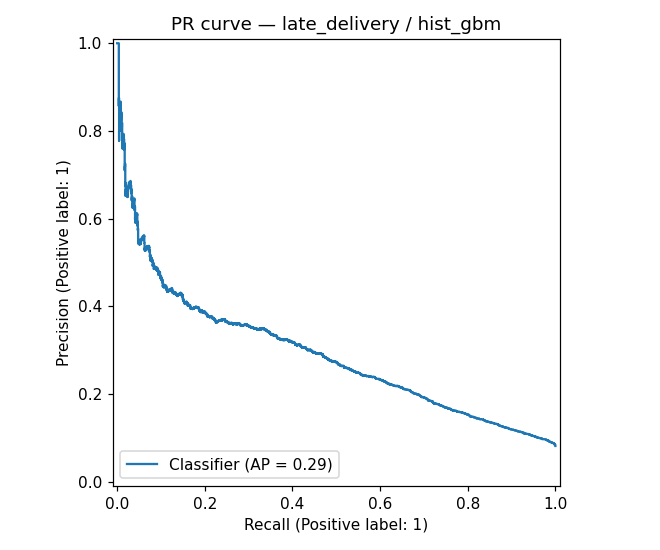

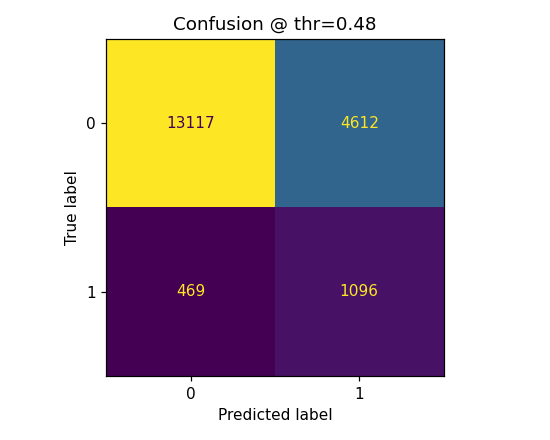

In [10]:
out_dir = resolve_path(cfg, cfg['output']['dir'])
paths = ev.plot_diagnostics(estimator, X_test, y_test, cfg, out_dir)
from IPython.display import Image, display
for p in paths:
    display(Image(filename=str(p)))

## 7. Feature importance — does it match the EDA?
If the model is sound, the EDA's drivers (state/lane, freight, promised lead time)
should surface as top features.

In [11]:
imp = ev.feature_importance(estimator, top_n=15)
imp

## 8. Persist artifacts
Saves `model.pkl` + `metrics.json` (+ plots) to `artifacts/`. This is exactly what
`run.sh` does headlessly.

In [12]:
pipeline.persist(estimator, metrics, cfg, out_dir, best_params)


💾 Saved model -> /Users/cheonghoongjun/Documents/dev/github-dev/sctp-dsai-forked/dsai-m2-elt/m2-elt/my-work/HoongJun/dev/p5_analytics/notebooks/mlp/artifacts/model.pkl
💾 Saved metrics -> /Users/cheonghoongjun/Documents/dev/github-dev/sctp-dsai-forked/dsai-m2-elt/m2-elt/my-work/HoongJun/dev/p5_analytics/notebooks/mlp/artifacts/metrics.json


## 9. The whole pipeline in one call
`pipeline.run(cfg)` chains every stage above — the same entry point `run.sh` invokes via
`python -m src.pipeline`. Demonstrates the notebook lifts cleanly into a script.

```bash
pip install -r requirements.txt      # deps installed separately
./run.sh                             # uses config.yaml
./run.sh --set model.name=random_forest --set search.enabled=true
MLP_TARGET=repeat_purchase ./run.sh  # secondary task, no code change
```

In [13]:
# metrics = pipeline.run(load_config())   # uncomment to run the full chain end-to-end

## 10. Results & deployment notes
Fill `mlp-plan-result.md` §B from the metrics above. Deployment considerations
(plan §A.8): scheduled retrain on a rolling window (BQ ingestion makes this a cron),
input + label drift monitoring against the 8.1% baseline, low-latency single-row scoring
with the fitted `Pipeline` guaranteeing train/serve parity, input validation on
freight/weight/state, and reproducibility via fixed seeds + pinned `requirements.txt`
+ versioned config and model artifact.